Détection de Fraude par IA — Projet Fintech GTA
**Ordre d'exécution : lancer les cellules UNE PAR UNE dans l'ordre**

## 📦 CELLULE 1 — Imports et configuration

In [1]:
# ── Imports ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.preprocessing     import StandardScaler
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

# XGBoost
from xgboost import XGBClassifier

# Rééquilibrage
from imblearn.over_sampling import SMOTE

# Style graphiques
plt.style.use('dark_background')
sns.set_palette('husl')

# Créer le dossier models/ si inexistant
os.makedirs('models', exist_ok=True)

print('✅ Tous les imports OK')
print(f'📁 Dossier models/ prêt')

✅ Tous les imports OK
📁 Dossier models/ prêt


## 📂 CELLULE 2 — Chargement du dataset

In [2]:
# ── Chargement ─────────────────────────────────────────────
df = pd.read_csv('creditcard.csv')

print('=' * 50)
print('📊 INFORMATIONS DU DATASET')
print('=' * 50)
print(f'Nombre de transactions  : {len(df):,}')
print(f'Nombre de colonnes      : {df.shape[1]}')
print(f'Colonnes                : {list(df.columns)}')
print()

# Répartition fraude / légitime
fraude    = df['Class'].sum()
legitime  = len(df) - fraude
ratio     = fraude / len(df) * 100

print('🔍 RÉPARTITION DES CLASSES')
print(f'  Transactions légitimes : {legitime:,}  ({100-ratio:.2f}%)')
print(f'  Transactions frauduleuses : {fraude:,}  ({ratio:.4f}%)')
print()
print('⚠️  Déséquilibre important → on utilisera SMOTE pour corriger')

df.head()

📊 INFORMATIONS DU DATASET
Nombre de transactions  : 284,807
Nombre de colonnes      : 31
Colonnes                : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

🔍 RÉPARTITION DES CLASSES
  Transactions légitimes : 284,315  (99.83%)
  Transactions frauduleuses : 492  (0.1727%)

⚠️  Déséquilibre important → on utilisera SMOTE pour corriger


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 🔍 CELLULE 3 — Exploration des données (EDA)

In [3]:
# ── Statistiques générales ─────────────────────────────────
print('VALEURS MANQUANTES :')
print(df.isnull().sum().sum(), '← doit être 0')
print()

print('TYPES DE DONNÉES :')
print(df.dtypes.value_counts())
print()

# Statistiques sur le montant
print('STATISTIQUES SUR LE MONTANT (Amount) :')
print(df.groupby('Class')['Amount'].describe().round(2))
print()
print('  Class 0 = Légitime | Class 1 = Fraude')

VALEURS MANQUANTES :
0 ← doit être 0

TYPES DE DONNÉES :
float64    30
int64       1
Name: count, dtype: int64

STATISTIQUES SUR LE MONTANT (Amount) :
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87

  Class 0 = Légitime | Class 1 = Fraude


## 📊 CELLULE 4 — Visualisations

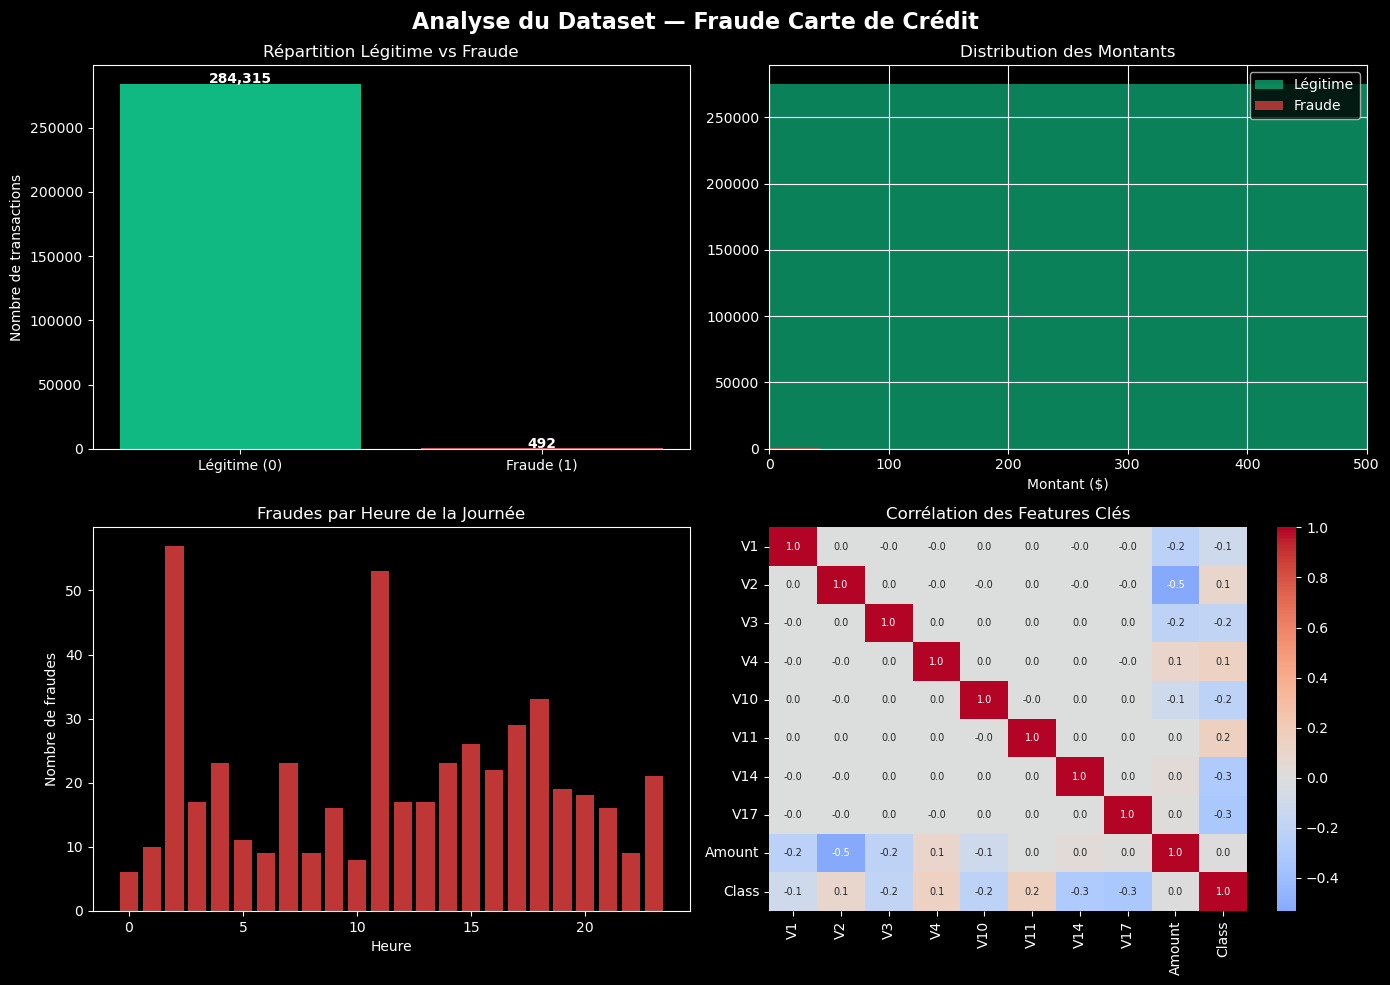

✅ Graphiques sauvegardés dans models/eda_plots.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse du Dataset — Fraude Carte de Crédit', 
             fontsize=16, fontweight='bold', color='white')

# ── Graphique 1 : Répartition des classes ─────────────────
counts = df['Class'].value_counts()
colors = ['#10B981', '#EF4444']
axes[0,0].bar(['Légitime (0)', 'Fraude (1)'], counts.values, color=colors)
axes[0,0].set_title('Répartition Légitime vs Fraude')
axes[0,0].set_ylabel('Nombre de transactions')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold', color='white')

# ── Graphique 2 : Distribution du montant par classe ──────
df[df['Class']==0]['Amount'].hist(bins=50, ax=axes[0,1], 
    color='#10B981', alpha=0.7, label='Légitime')
df[df['Class']==1]['Amount'].hist(bins=50, ax=axes[0,1], 
    color='#EF4444', alpha=0.7, label='Fraude')
axes[0,1].set_title('Distribution des Montants')
axes[0,1].set_xlabel('Montant ($)')
axes[0,1].legend()
axes[0,1].set_xlim(0, 500)

# ── Graphique 3 : Fraudes par heure ───────────────────────
df['Hour'] = (df['Time'] / 3600).astype(int) % 24
fraud_by_hour = df[df['Class']==1].groupby('Hour').size()
axes[1,0].bar(fraud_by_hour.index, fraud_by_hour.values, color='#EF4444', alpha=0.8)
axes[1,0].set_title('Fraudes par Heure de la Journée')
axes[1,0].set_xlabel('Heure')
axes[1,0].set_ylabel('Nombre de fraudes')

# ── Graphique 4 : Corrélation Amount + features clés ──────
top_features = ['V1','V2','V3','V4','V10','V11','V14','V17','Amount','Class']
corr = df[top_features].corr()
sns.heatmap(corr, ax=axes[1,1], cmap='coolwarm', center=0,
            annot=True, fmt='.1f', annot_kws={'size': 7})
axes[1,1].set_title('Corrélation des Features Clés')

plt.tight_layout()
plt.savefig('models/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphiques sauvegardés dans models/eda_plots.png')

## 🔧 CELLULE 5 — Préparation des données

In [5]:
# ── Sélection des features ─────────────────────────────────
# V1-V28 = features anonymisées (PCA)
# Amount = montant de la transaction
# Time   = secondes depuis la 1ère transaction
# Class  = 0 (légitime) ou 1 (fraude) → c'est notre CIBLE

# On garde toutes les features V + Amount + Time
feature_cols = [col for col in df.columns if col != 'Class']
X = df[feature_cols].copy()
y = df['Class'].copy()

print(f'Features utilisées : {len(feature_cols)}')
print(f'Exemples (X) : {X.shape}')
print(f'Cible (y)    : {y.shape}')
print()

# ── Normalisation de Amount et Time ───────────────────────
# V1-V28 sont déjà normalisées (PCA)
# Seules Amount et Time ont besoin de scaling
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

print('✅ Amount et Time normalisés')
print(f'  Amount → moyenne: {X["Amount"].mean():.4f}, std: {X["Amount"].std():.4f}')
print()

# ── Découpage train / test ─────────────────────────────────
# stratify=y → préserver le ratio fraude/légitime dans les deux sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% entraînement, 20% test
    random_state=42,    # reproductibilité
    stratify=y          # important pour les données déséquilibrées
)

print(f'Données entraînement : {X_train.shape[0]:,} transactions')
print(f'Données test         : {X_test.shape[0]:,} transactions')
print(f'Fraudes dans train   : {y_train.sum():,}')
print(f'Fraudes dans test    : {y_test.sum():,}')

Features utilisées : 31
Exemples (X) : (284807, 31)
Cible (y)    : (284807,)

✅ Amount et Time normalisés
  Amount → moyenne: -0.0000, std: 1.0000

Données entraînement : 227,845 transactions
Données test         : 56,962 transactions
Fraudes dans train   : 394
Fraudes dans test    : 98


## ⚖️ CELLULE 6 — Rééquilibrage avec SMOTE

In [6]:
# ── Problème : 99.8% légitime vs 0.2% fraude ──────────────
# Sans correction, le modèle prédit toujours 'légitime' et a 99.8% d'accuracy
# mais détecte 0 fraude → inutile !

# SMOTE : Synthetic Minority Over-sampling Technique
# Crée de nouvelles transactions frauduleuses SYNTHÉTIQUES
# pour équilibrer le dataset d'entraînement

print('Avant SMOTE :')
print(f'  Légitimes : {(y_train==0).sum():,}')
print(f'  Fraudes   : {(y_train==1).sum():,}')
print()

smote = SMOTE(random_state=42, sampling_strategy=0.1)
# sampling_strategy=0.1 → 10% de fraudes (pas 50% pour rester réaliste)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Après SMOTE :')
print(f'  Légitimes : {(y_train_sm==0).sum():,}')
print(f'  Fraudes   : {(y_train_sm==1).sum():,}')
print(f'  Ratio fraude : {(y_train_sm==1).sum()/len(y_train_sm)*100:.1f}%')
print()
print('✅ Dataset équilibré — le modèle va apprendre à détecter les fraudes')

Avant SMOTE :
  Légitimes : 227,451
  Fraudes   : 394

Après SMOTE :
  Légitimes : 227,451
  Fraudes   : 22,745
  Ratio fraude : 9.1%

✅ Dataset équilibré — le modèle va apprendre à détecter les fraudes


## CELLULE 7 — Entraînement Random Forest

In [7]:
print(' Entraînement Random Forest en cours...')
print('   (peut prendre 1-3 minutes)')
print()

rf_model = RandomForestClassifier(
    n_estimators=100,       # 100 arbres de décision
    max_depth=15,           # profondeur max de chaque arbre
    min_samples_split=10,   # min 10 exemples pour diviser un nœud
    class_weight='balanced',# donner plus de poids aux fraudes
    random_state=42,
    n_jobs=-1               # utiliser tous les CPU disponibles
)

rf_model.fit(X_train_sm, y_train_sm)

# ── Évaluation ──────────────────────────────────────────────
y_pred_rf    = rf_model.predict(X_test)
y_proba_rf   = rf_model.predict_proba(X_test)[:, 1]
auc_rf       = roc_auc_score(y_test, y_proba_rf)
f1_rf        = f1_score(y_test, y_pred_rf)

print('=' * 50)
print('📊 RÉSULTATS RANDOM FOREST')
print('=' * 50)
print(classification_report(y_test, y_pred_rf,
      target_names=['Légitime', 'Fraude']))
print(f'AUC-ROC  : {auc_rf:.4f}')
print(f'F1-Score : {f1_rf:.4f}')

🌲 Entraînement Random Forest en cours...
   (peut prendre 1-3 minutes)

📊 RÉSULTATS RANDOM FOREST
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.66      0.86      0.74        98

    accuracy                           1.00     56962
   macro avg       0.83      0.93      0.87     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC  : 0.9795
F1-Score : 0.7434


## ⚡ CELLULE 8 — Entraînement XGBoost

In [8]:
# Ratio pour donner plus de poids aux fraudes
scale_pos = int((y_train_sm==0).sum() / (y_train_sm==1).sum())

print('⚡ Entraînement XGBoost en cours...')
print()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,  # compenser le déséquilibre
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb   = xgb_model.predict(X_test)
y_proba_xgb  = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb      = roc_auc_score(y_test, y_proba_xgb)
f1_xgb       = f1_score(y_test, y_pred_xgb)

print('=' * 50)
print('📊 RÉSULTATS XGBOOST')
print('=' * 50)
print(classification_report(y_test, y_pred_xgb,
      target_names=['Légitime', 'Fraude']))
print(f'AUC-ROC  : {auc_xgb:.4f}')
print(f'F1-Score : {f1_xgb:.4f}')

⚡ Entraînement XGBoost en cours...

📊 RÉSULTATS XGBOOST
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.71      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC  : 0.9802
F1-Score : 0.7742


## 🏆 CELLULE 9 — Comparaison et choix du meilleur modèle

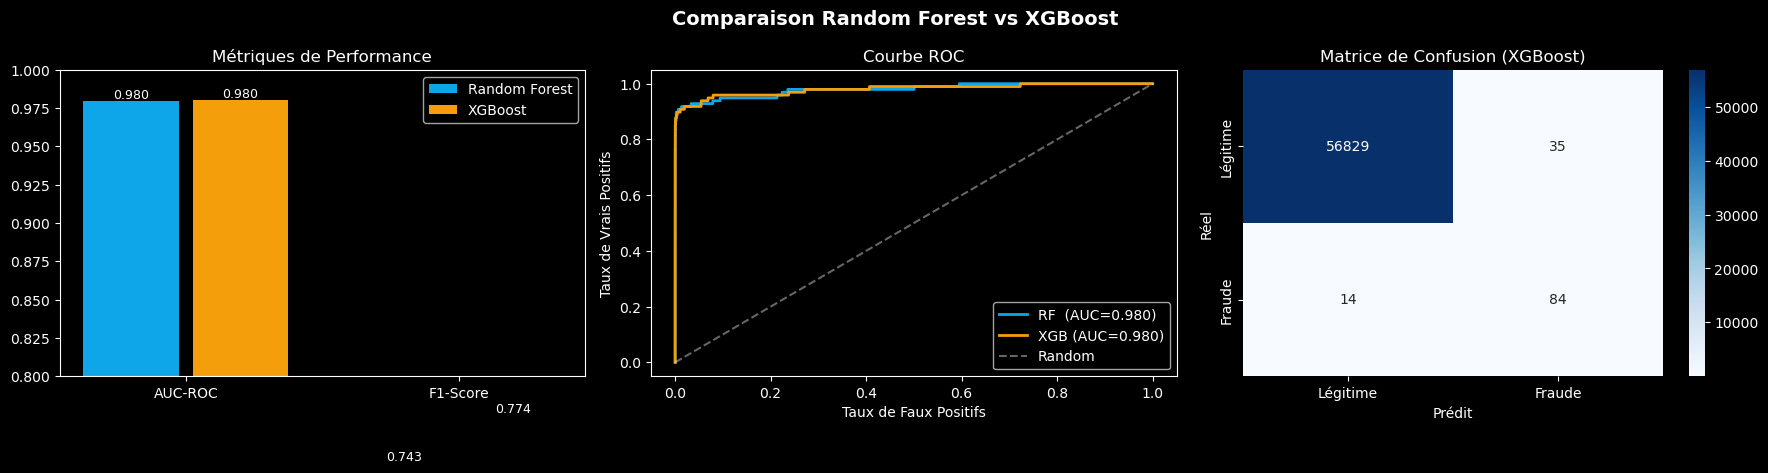

🏆 TABLEAU COMPARATIF FINAL
  Random Forest → AUC: 0.9795 | F1: 0.7434
  XGBoost       → AUC: 0.9802 | F1: 0.7742

✅ MODÈLE CHOISI : XGBoost (meilleur F1-Score)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparaison Random Forest vs XGBoost', 
             fontsize=14, fontweight='bold')

# ── Graphique 1 : Tableau comparatif ──────────────────────
metrics = ['AUC-ROC', 'F1-Score']
rf_scores  = [auc_rf,  f1_rf]
xgb_scores = [auc_xgb, f1_xgb]
x = np.arange(len(metrics))
axes[0].bar(x - 0.2, rf_scores,  0.35, label='Random Forest', color='#0EA5E9')
axes[0].bar(x + 0.2, xgb_scores, 0.35, label='XGBoost',       color='#F59E0B')
axes[0].set_ylim(0.8, 1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title('Métriques de Performance')
axes[0].legend()
for i, (r, x_) in enumerate(zip(rf_scores, xgb_scores)):
    axes[0].text(i-0.2, r+0.002, f'{r:.3f}', ha='center', fontsize=9)
    axes[0].text(i+0.2, x_+0.002, f'{x_:.3f}', ha='center', fontsize=9)

# ── Graphique 2 : Courbes ROC ──────────────────────────────
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
axes[1].plot(fpr_rf,  tpr_rf,  color='#0EA5E9', label=f'RF  (AUC={auc_rf:.3f})',  lw=2)
axes[1].plot(fpr_xgb, tpr_xgb, color='#F59E0B', label=f'XGB (AUC={auc_xgb:.3f})', lw=2)
axes[1].plot([0,1],[0,1], 'w--', alpha=0.4, label='Random')
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC')
axes[1].legend()

# ── Graphique 3 : Matrice de confusion du meilleur ─────────
best_pred = y_pred_rf if f1_rf >= f1_xgb else y_pred_xgb
best_name = 'Random Forest' if f1_rf >= f1_xgb else 'XGBoost'
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Légitime','Fraude'],
            yticklabels=['Légitime','Fraude'])
axes[2].set_title(f'Matrice de Confusion ({best_name})')
axes[2].set_ylabel('Réel')
axes[2].set_xlabel('Prédit')

plt.tight_layout()
plt.savefig('models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Décision finale ────────────────────────────────────────
print('=' * 50)
print('🏆 TABLEAU COMPARATIF FINAL')
print('=' * 50)
print(f'  Random Forest → AUC: {auc_rf:.4f} | F1: {f1_rf:.4f}')
print(f'  XGBoost       → AUC: {auc_xgb:.4f} | F1: {f1_xgb:.4f}')
print()

if f1_rf >= f1_xgb:
    best_model = rf_model
    print('✅ MODÈLE CHOISI : Random Forest (meilleur F1-Score)')
else:
    best_model = xgb_model
    print('✅ MODÈLE CHOISI : XGBoost (meilleur F1-Score)')

## 💾 CELLULE 10 — Sauvegarde des modèles

In [10]:
# ── Sauvegarder le scaler ──────────────────────────────────
# IMPORTANT : sauvegarder le même scaler utilisé à l'entraînement
# Pour que les prédictions en production soient cohérentes
joblib.dump(scaler, 'models/scaler.pkl')
print('✅ Scaler sauvegardé → models/scaler.pkl')

# ── Sauvegarder le meilleur modèle ────────────────────────
joblib.dump(best_model, 'models/fraud_detector.pkl')
print('✅ Modèle fraude sauvegardé → models/fraud_detector.pkl')

# ── Sauvegarder aussi les deux pour comparaison ───────────
joblib.dump(rf_model,  'models/random_forest.pkl')
joblib.dump(xgb_model, 'models/xgboost.pkl')
print('✅ RF et XGBoost individuels sauvegardés')

# ── Sauvegarder les colonnes (important pour Flask) ───────
import json
with open('models/feature_columns.json', 'w') as f:
    json.dump(list(X.columns), f)
print('✅ Noms des features sauvegardés → models/feature_columns.json')

print()
print('📁 Contenu du dossier models/ :')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'   {f} ({size:.0f} KB)')

✅ Scaler sauvegardé → models/scaler.pkl
✅ Modèle fraude sauvegardé → models/fraud_detector.pkl
✅ RF et XGBoost individuels sauvegardés
✅ Noms des features sauvegardés → models/feature_columns.json

📁 Contenu du dossier models/ :
   eda_plots.png (159 KB)
   feature_columns.json (0 KB)
   fraud_detector.pkl (667 KB)
   model_comparison.png (129 KB)
   random_forest.pkl (8298 KB)
   scaler.pkl (1 KB)
   xgboost.pkl (667 KB)


## 📊 CELLULE 11 — Feature Importance

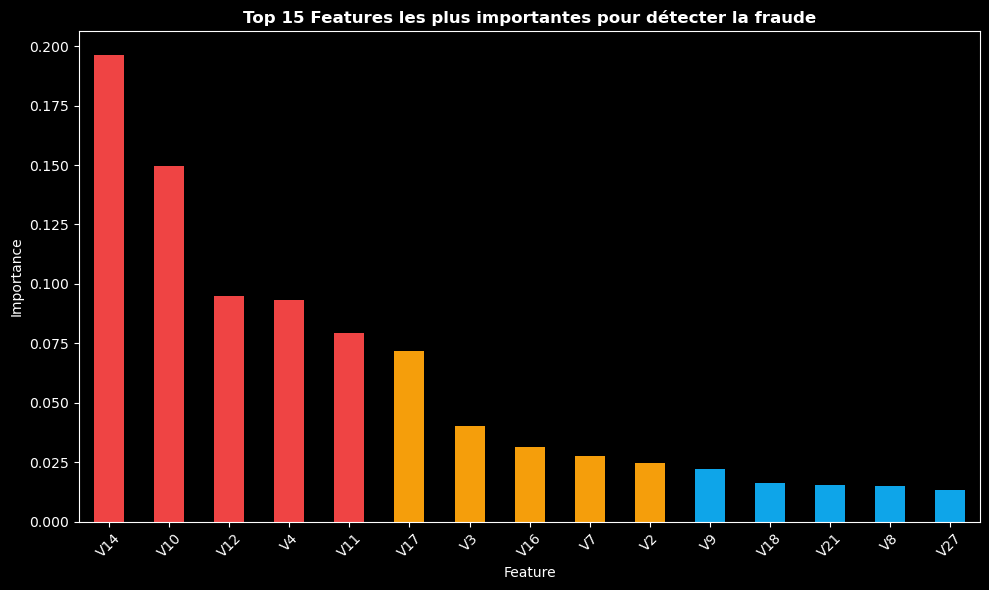

Top 5 features les plus importantes :
  V14    → 0.1965
  V10    → 0.1497
  V12    → 0.0949
  V4     → 0.0933
  V11    → 0.0792


In [11]:
# Quelles features déclenchent le plus les alertes fraude ?
# Utile pour expliquer le modèle lors de la soutenance

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#EF4444' if i < 5 else '#F59E0B' if i < 10 else '#0EA5E9' 
          for i in range(15)]
top15.plot(kind='bar', ax=ax, color=colors, edgecolor='none')
ax.set_title('Top 15 Features les plus importantes pour détecter la fraude',
             fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features les plus importantes :')
for feat, score in importances.head(5).items():
    print(f'  {feat:6s} → {score:.4f}')

## 🧪 CELLULE 12 — Test de prédiction (simulation Flask)

In [12]:
# Simuler exactement ce que Flask va faire quand il reçoit
# une transaction depuis l'interface web

def predict_fraud(transaction_features: list) -> dict:
    """
    Fonction de prédiction — exactement celle utilisée dans Flask
    Input  : liste de valeurs [V1, V2, ..., V28, Amount, Time]
    Output : dict avec score et décision
    """
    # Charger le modèle et le scaler
    model  = joblib.load('models/fraud_detector.pkl')
    sc     = joblib.load('models/scaler.pkl')

    # Créer le DataFrame avec les bons noms de colonnes
    with open('models/feature_columns.json') as f:
        cols = json.load(f)

    df_tx = pd.DataFrame([transaction_features], columns=cols)

    # Normaliser Amount et Time
    df_tx[['Amount', 'Time']] = sc.transform(df_tx[['Amount', 'Time']])

    # Prédiction
    proba      = model.predict_proba(df_tx)[0]
    fraud_prob = float(proba[1])
    risk_score = int(fraud_prob * 100)

    # Catégorisation
    if fraud_prob < 0.30:
        risk_level = 'LOW'
        blocked    = False
        emoji      = '🟢'
    elif fraud_prob < 0.60:
        risk_level = 'MEDIUM'
        blocked    = False
        emoji      = '🟡'
    elif fraud_prob < 0.85:
        risk_level = 'HIGH'
        blocked    = True
        emoji      = '🟠'
    else:
        risk_level = 'CRITICAL'
        blocked    = True
        emoji      = '🔴'

    return {
        'fraud_probability': round(fraud_prob, 4),
        'risk_score'       : risk_score,
        'risk_level'       : risk_level,
        'blocked'          : blocked,
        'emoji'            : emoji
    }

# ── Test avec une vraie transaction légitime du dataset ───
print('TEST 1 — Transaction légitime (tirée du dataset) :')
legitimate_tx = X_test[y_test == 0].iloc[0].tolist()
result1 = predict_fraud(legitimate_tx)
for k, v in result1.items():
    print(f'  {k:20s}: {v}')

print()
print('TEST 2 — Transaction frauduleuse (tirée du dataset) :')
fraud_tx = X_test[y_test == 1].iloc[0].tolist()
result2 = predict_fraud(fraud_tx)
for k, v in result2.items():
    print(f'  {k:20s}: {v}')

print()
print('✅ La fonction predict_fraud() fonctionne correctement')
print('   → Prête à être importée dans Flask (app.py)')

TEST 1 — Transaction légitime (tirée du dataset) :
  fraud_probability   : 0.0
  risk_score          : 0
  risk_level          : LOW
  blocked             : False
  emoji               : 🟢

TEST 2 — Transaction frauduleuse (tirée du dataset) :
  fraud_probability   : 0.9984
  risk_score          : 99
  risk_level          : CRITICAL
  blocked             : True
  emoji               : 🔴

✅ La fonction predict_fraud() fonctionne correctement
   → Prête à être importée dans Flask (app.py)
